In [ ]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

diabetes = load_diabetes()
df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
df['target'] = diabetes.target

X = df[['bmi']]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(X_train.shape, X_test.shape)

(309, 1) (133, 1)


In [ ]:
tree = DecisionTreeRegressor(max_depth=3, random_state=42)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

print(f"R² (test) = {r2_score(y_test, y_pred_tree):.4f}")

R² (test) = 0.2781


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


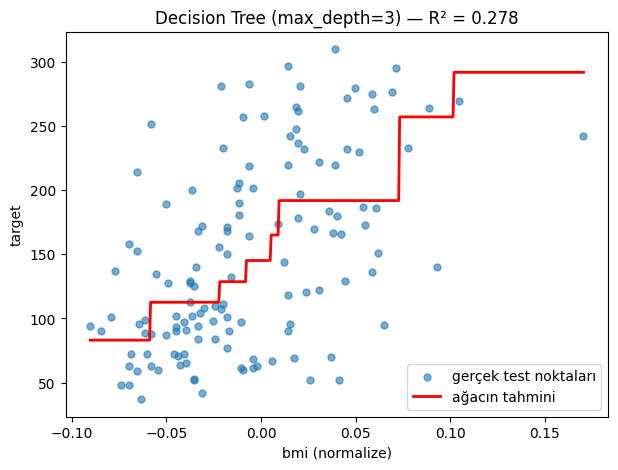

In [ ]:
grid = np.linspace(X['bmi'].min(), X['bmi'].max(), 500).reshape(-1, 1)
grid_pred = tree.predict(grid)

plt.figure(figsize=(7, 5))
plt.scatter(X_test, y_test, alpha=0.6, s=25, label='gerçek test noktaları')
plt.plot(grid, grid_pred, color='red', linewidth=2, label='ağacın tahmini')
plt.xlabel('bmi (normalize)')
plt.ylabel('target')
plt.title(f'Decision Tree (max_depth=3) — R² = {r2_score(y_test, y_pred_tree):.3f}')
plt.legend()
plt.show()

In [ ]:
for depth in [2, 3, 5, None]:
    t = DecisionTreeRegressor(max_depth=depth, random_state=42)
    t.fit(X_train, y_train)
    train_r2 = r2_score(y_train, t.predict(X_train))
    test_r2 = r2_score(y_test, t.predict(X_test))
    print(f"max_depth={str(depth):5s}  train R²={train_r2:.4f}   test R²={test_r2:.4f}")

max_depth=2      train R²=0.3926   test R²=0.2748
max_depth=3      train R²=0.4116   test R²=0.2781
max_depth=5      train R²=0.4659   test R²=0.2427
max_depth=None   train R²=0.6300   test R²=0.1187


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


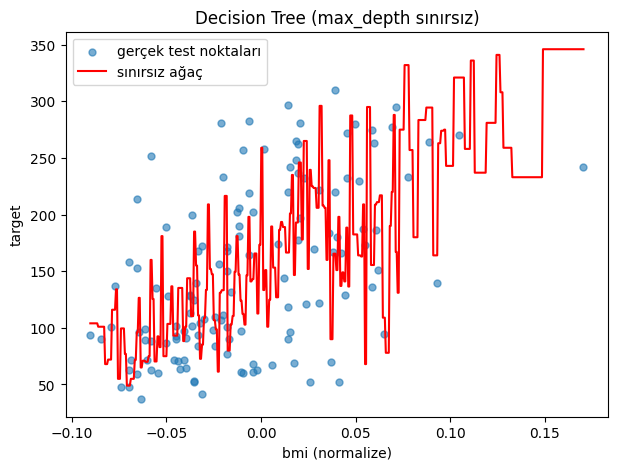

In [ ]:
tree_full = DecisionTreeRegressor(random_state=42)
tree_full.fit(X_train, y_train)

grid_pred_full = tree_full.predict(grid)

plt.figure(figsize=(7, 5))
plt.scatter(X_test, y_test, alpha=0.6, s=25, label='gerçek test noktaları')
plt.plot(grid, grid_pred_full, color='red', linewidth=1.5, label='sınırsız ağaç')
plt.xlabel('bmi (normalize)')
plt.ylabel('target')
plt.title('Decision Tree (max_depth sınırsız)')
plt.legend()
plt.show()

## Gözlemler

- Aynı veri, aynı özellik (bmi), aynı split (random_state=42) kullandım ki
  Task C ile doğrudan karşılaştırılabilsin.
- max_depth=3 ile R² = 0.2781 çıktı. Task C'deki linear regression 0.2803
  vermişti — pratikte aynı. İki tamamen farklı algoritma aynı sonucu verdi,
  çünkü bmi ile target arasındaki ilişki zaten kabaca doğrusal; ağacın
  esnekliği burada fazladan bir şey kazandırmıyor.
- Skorlar aynı ama ŞEKİL çok farklı: linear regression düz bir çizgi çiziyor,
  ağaç ise merdiven şeklinde basamaklar üretiyor. Sebebi ağacın bmi aralığını
  bölgelere ayırıp her bölgedeki tüm hastalara tek bir sayı (o yaprağın
  ortalaması) vermesi. Bölge içinde tahmin sabit, sınırı geçince aniden
  zıplıyor. Ayrıca iki uçtaki basamaklar yatay uzuyor — ağaç gördüğü aralığın
  dışına çıkamıyor.
- max_depth'i artırdıkça train ve test R² ters yönlere gitti:
  depth=2 → train 0.39 / test 0.27
  depth=3 → train 0.41 / test 0.28
  depth=5 → train 0.47 / test 0.24
  sınırsız → train 0.63 / test 0.12
  Bu tam olarak overfitting. Sınırsız ağaç eğitim verisini iki kat daha iyi
  biliyor ama yeni veride linear regression'ın yarısı kadar işe yarıyor.
- Sınırsız ağacın grafiği dişli ve titrek bir çizgi — bir örüntü değil,
  gürültünün ezberlenmiş hali. Aynı bmi değerinde target 50 de olabiliyor
  300 de, ağaç bunların hepsinin üzerinden geçmeye çalışıyor.
- En çarpıcı bulgu: modeli frenlemek (derinliği sınırlamak) onu güçlendirdi.
  max_depth=2 bile sınırsız ağacın iki katından iyi test skoru verdi.